In [26]:
mat_path = "observables.mat"   # change this to your file
import h5py

with h5py.File(mat_path, "r") as f:
    print(list(f.keys()))
    for k in f.keys():
        obj = f[k]
        print(k, obj.shape if hasattr(obj, "shape") else type(obj))

['Carrier_Doppler_hz', 'Carrier_phase_cycles', 'Flag_valid_pseudorange', 'PRN', 'Pseudorange_m', 'RX_time', 'TOW_at_current_symbol_s']
Carrier_Doppler_hz (17457, 20)
Carrier_phase_cycles (17457, 20)
Flag_valid_pseudorange (17457, 20)
PRN (17457, 20)
Pseudorange_m (17457, 20)
RX_time (17457, 20)
TOW_at_current_symbol_s (17457, 20)


In [27]:
import h5py
import numpy as np


with h5py.File(mat_path, "r") as f:
    Flag_valid_pseudorange = np.array(f["Flag_valid_pseudorange"])
    PRN = np.array(f["PRN"])
    Pseudorange_m = np.array(f["Pseudorange_m"])
    RX_time = np.array(f["RX_time"])
    TOW_at_current_symbol_s = np.array(f["TOW_at_current_symbol_s"])

print("Shape:", Flag_valid_pseudorange.shape)   # should be (8, 4868)

valid = Flag_valid_pseudorange > 0

# count valid sats per epoch: sum across channels
valid_counts = np.sum(valid, axis=0)

print("Max valid sats in any epoch:", np.max(valid_counts))
print("Epochs with >=4 valid sats:", np.sum(valid_counts >= 4))

best_idx = np.argmax(valid_counts)
mask = valid[:, best_idx]

print("\nBest epoch index:", best_idx)
print("Valid sats at best epoch:", valid_counts[best_idx])
print("PRNs at best epoch:", PRN[:, best_idx][mask])
print("Pseudoranges at best epoch:", Pseudorange_m[:, best_idx][mask])
print("RX times at best epoch:", RX_time[:, best_idx][mask])
print("TOW at best epoch:", TOW_at_current_symbol_s[:, best_idx][mask])

Shape: (17457, 20)
Max valid sats in any epoch: 14700
Epochs with >=4 valid sats: 5

Best epoch index: 1
Valid sats at best epoch: 14700
PRNs at best epoch: [9. 9. 9. ... 9. 9. 9.]
Pseudoranges at best epoch: [5638218.7096104  5638218.6760569  5638218.66298887 ... -357630.43055416
 -357630.42697686 -357630.42462108]
RX times at best epoch: [ 30.02  30.04  30.06 ... 361.02 361.04 361.06]
TOW at best epoch: [ 30.00119293  30.02119293  30.04119293 ... 361.02119293 361.04119293
 361.06119293]


In [28]:
import h5py
import numpy as np
import pandas as pd

with h5py.File(mat_path, "r") as f:
    data = {k: np.array(f[k]) for k in f.keys()}

# Your file is channels x epochs
# shape should be (8, 4868)
for k, v in data.items():
    print(k, v.shape)

Flag_valid_pseudorange = data["Flag_valid_pseudorange"]
PRN = data["PRN"]
Pseudorange_m = data["Pseudorange_m"]
Carrier_Doppler_hz = data["Carrier_Doppler_hz"]
Carrier_phase_cycles = data["Carrier_phase_cycles"]
RX_time = data["RX_time"]
TOW_at_current_symbol_s = data["TOW_at_current_symbol_s"]

n_channels, n_epochs = Flag_valid_pseudorange.shape
print("channels:", n_channels, "epochs:", n_epochs)

# Treat positive flag as valid
valid = Flag_valid_pseudorange > 0

# Count valid sats per epoch
valid_counts = valid.sum(axis=0)

best_epoch = int(np.argmax(valid_counts))
print("Max valid sats in an epoch:", int(valid_counts[best_epoch]))
print("Best epoch index:", best_epoch)

# Pull the valid satellite rows at that epoch
mask = valid[:, best_epoch]

epoch_df = pd.DataFrame({
    "channel": np.arange(n_channels)[mask],
    "PRN": PRN[:, best_epoch][mask],
    "pseudorange_m": Pseudorange_m[:, best_epoch][mask],
    "doppler_hz": Carrier_Doppler_hz[:, best_epoch][mask],
    "carrier_phase_cycles": Carrier_phase_cycles[:, best_epoch][mask],
    "rx_time": RX_time[:, best_epoch][mask],
    "tow_s": TOW_at_current_symbol_s[:, best_epoch][mask],
    "valid_flag": Flag_valid_pseudorange[:, best_epoch][mask],
})

print("\nBest epoch data:")
print(epoch_df)

# Build a full long table of all valid measurements
rows = []
for e in range(n_epochs):
    mask = valid[:, e]
    if not np.any(mask):
        continue

    for ch in np.where(mask)[0]:
        rows.append({
            "epoch": e,
            "channel": int(ch),
            "PRN": float(PRN[ch, e]),
            "pseudorange_m": float(Pseudorange_m[ch, e]),
            "doppler_hz": float(Carrier_Doppler_hz[ch, e]),
            "carrier_phase_cycles": float(Carrier_phase_cycles[ch, e]),
            "rx_time": float(RX_time[ch, e]),
            "tow_s": float(TOW_at_current_symbol_s[ch, e]),
            "valid_flag": float(Flag_valid_pseudorange[ch, e]),
        })

all_valid_df = pd.DataFrame(rows)

print("\nAll valid measurements:")
print(all_valid_df.head())
print("\nTotal valid measurements:", len(all_valid_df))

# Save for inspection
epoch_df.to_csv("best_epoch_measurements.csv", index=False)
all_valid_df.to_csv("all_valid_measurements.csv", index=False)

print("\nSaved:")
print("  best_epoch_measurements.csv")
print("  all_valid_measurements.csv")

Carrier_Doppler_hz (17457, 20)
Carrier_phase_cycles (17457, 20)
Flag_valid_pseudorange (17457, 20)
PRN (17457, 20)
Pseudorange_m (17457, 20)
RX_time (17457, 20)
TOW_at_current_symbol_s (17457, 20)
channels: 17457 epochs: 20
Max valid sats in an epoch: 14700
Best epoch index: 1

Best epoch data:
       channel  PRN  pseudorange_m   doppler_hz  carrier_phase_cycles  \
0          903  9.0   5.638219e+06  3748.966222         -4.290444e+04   
1          904  9.0   5.638219e+06  3748.807918         -4.297942e+04   
2          905  9.0   5.638219e+06  3748.439130         -4.305440e+04   
3          906  9.0   5.638219e+06  3749.131544         -4.312938e+04   
4          907  9.0   5.638219e+06  3749.552906         -4.320436e+04   
...        ...  ...            ...          ...                   ...   
14695    17452  9.0  -3.576304e+05  3687.505790         -1.273716e+06   
14696    17453  9.0  -3.576304e+05  3686.887893         -1.273790e+06   
14697    17454  9.0  -3.576304e+05  3686.899231

In [ ]:
import matplotlib.pyplot as plt

# Make sure PRN is integer-like
all_valid_df["PRN"] = all_valid_df["PRN"].astype(int)

# Sort so each PRN line is drawn in order
all_valid_df = all_valid_df.sort_values(["PRN", "epoch"])

# Option 1: print/extract all Doppler values for each PRN
doppler_by_prn = {
    prn: grp["doppler_hz"].to_numpy()
    for prn, grp in all_valid_df.groupby("PRN")
}

for prn, vals in doppler_by_prn.items():
    print(f"PRN {prn}:")
    print(vals)
    print(len(vals))
    print()



PRN 3:
[-307.6531901  -307.5985678  -307.6849203  ... -476.61728909 -477.19221396
 -477.2678447 ]
14604

PRN 4:
[2552.99152475 2552.39743417 2552.37837107 ... 2396.68758545 2396.67465516
 2396.49269446]
14607

PRN 6:
[3261.52318016 3261.37628496 3261.91372737 ... 3180.56109468 3180.40730747
 3180.49281071]
14696

PRN 9:
[3748.96622161 3748.80791822 3748.43912993 ... 3686.89923062 3686.38103064
 3686.73258444]
14700

PRN 31:
[1636.88042666 1637.27391567 1637.821338   ... 1420.03687119 1419.73388117
 1420.21057642]
14623



In [30]:
doppler_by_prn[3]

array([-307.6531901 , -307.5985678 , -307.6849203 , ..., -476.61728909,
       -477.19221396, -477.2678447 ])

In [31]:
doppler_a=np.array([1648.372, 1647.73 , 1647.363, 1646.359, 1645.815, 1644.908,
       1644.818, 1643.62 , 1643.62 , 1644.179, 1643.608, 1641.755,
       1641.189, 1640.319, 1640.342, 1639.733, 1639.321, 1638.734,
       1637.549, 1635.971, 1635.556, 1634.856, 1633.735, 1634.396,
       1633.111, 1633.188, 1631.197, 1630.366, 1630.529, 1629.794,
       1628.247, 1627.526, 1627.276, 1626.259, 1626.953, 1625.982,
       1624.91 , 1624.683, 1624.876, 1624.12 , 1622.29 , 1622.6  ,
       1621.72 , 1621.474, 1620.797, 1618.958, 1618.377, 1618.029,
       1619.681, 1617.421])

doppler_b=vals

In [32]:
import pandas as pd
import numpy as np

C_MPS = 299_792_458.0

# load full extracted GPS observations
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# satellites and time window
sv_order = [ "G03", "G04", "G06","G07", "G09","G19","G21" , "G26", "G31"]
start_time = pd.Timestamp("2026-01-11 00:00:00")
end_time = start_time + pd.Timedelta(minutes=12.5)

# slice the window
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["time", "sv"]).reset_index(drop=True)
window_df["delay_s"] = window_df["C1C_m"] / C_MPS

print("rows:", len(window_df))
print("time min/max:", window_df["time"].min(), window_df["time"].max())
print("sats present:", window_df["sv"].unique())

# one dataframe per satellite BEFORE interpolation
sat_frames = {
    sv: grp.copy().reset_index(drop=True)
    for sv, grp in window_df.groupby("sv")
}

# print number of raw data points per satellite
print("\nraw data points per satellite:")
for sv in sv_order:
    n_points_before = len(sat_frames[sv]) if sv in sat_frames else 0
    print(f"{sv}: {n_points_before}")

# make sure all requested sats are present
for sv in sv_order:
    if sv not in sat_frames:
        print(f"Missing satellite: {sv}")

# build sat_data dict from raw observations
sat_data = {
    sv: {
        "time": sat_frames[sv]["time"].tolist(),
        "pseudorange_m": sat_frames[sv]["C1C_m"].tolist(),
        "delay_s": sat_frames[sv]["delay_s"].tolist(),
        "doppler_hz": sat_frames[sv]["D1C_hz"].tolist(),
    }
    for sv in sv_order
    if sv in sat_frames
}

# align into matrices with one common time index
pivot_pr = window_df.pivot(index="time", columns="sv", values="C1C_m").reindex(columns=sv_order)
pivot_delay = window_df.pivot(index="time", columns="sv", values="delay_s").reindex(columns=sv_order)
pivot_dopp = window_df.pivot(index="time", columns="sv", values="D1C_hz").reindex(columns=sv_order)

# count original non-missing data points before interpolation
print("\noriginal non-NaN points:")
print("pseudorange:", pivot_pr.notna().sum().sum())
print("delay:", pivot_delay.notna().sum().sum())
print("doppler:", pivot_dopp.notna().sum().sum())

# interpolate missing values inside the window
pivot_pr = pivot_pr.interpolate(limit_direction="both")
pivot_delay = pivot_delay.interpolate(limit_direction="both")
pivot_dopp = pivot_dopp.interpolate(limit_direction="both")

# arrays for simulator: shape = (n_sats, n_times)
pseudorange_list = pivot_pr.to_numpy(dtype=float).T
delay_list = pivot_delay.to_numpy(dtype=float).T
doppler_list = pivot_dopp.to_numpy(dtype=float).T
time_list = pivot_delay.index.to_numpy()

print("\ninterpolated array shapes:")
print("pseudorange_list shape:", pseudorange_list.shape)
print("delay_list shape:", delay_list.shape)
print("doppler_list shape:", doppler_list.shape)
print("time_list shape:", time_list.shape)

print("\ntotal matrix points after interpolation:")
print("pseudorange_list:", pseudorange_list.size)
print("delay_list:", delay_list.size)
print("doppler_list:", doppler_list.size)

# print RAW values before interpolation
print("\n===== RAW DATA PER SATELLITE (before interpolation) =====")
for sv in sv_order:
    if sv in sat_frames:
        raw_times = sat_frames[sv]["time"].to_numpy()
        raw_pr = sat_frames[sv]["C1C_m"].to_numpy()
        raw_delay = sat_frames[sv]["delay_s"].to_numpy()
        raw_dopp = sat_frames[sv]["D1C_hz"].to_numpy()
        n_points_before = len(raw_times)
    else:
        raw_times = np.array([])
        raw_pr = np.array([])
        raw_delay = np.array([])
        raw_dopp = np.array([])
        n_points_before = 0

    print(f"\n{sv}")
    print(" data points before interpolation:", n_points_before)
    print(" first raw times:", raw_times[:3])
    print(" first raw pseudoranges:", raw_pr[:3])
    print(" first raw delays:", raw_delay[:3])
    print(" first raw dopplers:", raw_dopp[:3])

# optional: print INTERPOLATED values separately
print("\n===== INTERPOLATED DATA PER SATELLITE =====")
for i, sv in enumerate(sv_order):
    print(f"\n{sv}")
    print(" first interpolated times:", time_list[:3])
    print(" first interpolated pseudoranges:", pseudorange_list[i, :3])
    print(" first interpolated delays:", delay_list[i, :3])
    print(" first interpolated dopplers:", doppler_list[i, :3])

sv_nums = [3, 4, 6, 9, 31]
#sv_order = [ "G03", "G04", "G06","G07", "G09","G19","G21" , "G26","G29", "G31"]

sv_labels = [f"G{i:02d}" for i in sv_nums]

doppler_list = np.array(
    [sat_frames[f"G{sv:02d}"]["D1C_hz"].tolist() for sv in sv_nums],
    dtype=float
)

rows: 4506
time min/max: 2026-01-11 00:00:00 2026-01-11 00:12:30
sats present: <StringArray>
['G03', 'G04', 'G06', 'G09', 'G19', 'G31']
Length: 6, dtype: str

raw data points per satellite:
G03: 751
G04: 751
G06: 751
G07: 0
G09: 751
G19: 751
G21: 0
G26: 0
G31: 751
Missing satellite: G07
Missing satellite: G21
Missing satellite: G26

original non-NaN points:
pseudorange: 4506
delay: 4506
doppler: 4506

interpolated array shapes:
pseudorange_list shape: (9, 751)
delay_list shape: (9, 751)
doppler_list shape: (9, 751)
time_list shape: (751,)

total matrix points after interpolation:
pseudorange_list: 6759
delay_list: 6759
doppler_list: 6759

===== RAW DATA PER SATELLITE (before interpolation) =====

G03
 data points before interpolation: 751
 first raw times: ['2026-01-11T00:00:00.000000' '2026-01-11T00:00:01.000000'
 '2026-01-11T00:00:02.000000']
 first raw pseudoranges: [19922865.917 19922922.998 19922980.16 ]
 first raw delays: [0.06645553 0.06645572 0.06645591]
 first raw dopplers: [-

In [33]:
doppler_list[0][:350]

array([-299.556, -299.885, -300.313, -300.954, -301.593, -302.261,
       -302.28 , -303.431, -303.127, -302.523, -302.891, -304.782,
       -305.072, -305.826, -305.685, -306.237, -306.498, -306.91 ,
       -307.988, -309.465, -309.673, -310.217, -311.343, -310.539,
       -311.704, -311.543, -313.19 , -313.991, -313.665, -314.19 ,
       -315.703, -316.385, -316.382, -317.251, -316.512, -317.318,
       -318.308, -318.409, -318.087, -318.645, -320.379, -319.969,
       -320.621, -320.756, -321.302, -322.858, -323.608, -323.546,
       -321.816, -324.085, -325.515, -324.943, -325.973, -327.323,
       -327.286, -327.298, -329.149, -328.97 , -328.826, -329.391,
       -329.915, -330.615, -330.219, -331.319, -332.083, -332.973,
       -334.14 , -334.151, -333.875, -334.211, -334.733, -335.585,
       -335.925, -336.676, -337.352, -337.33 , -338.043, -338.723,
       -339.647, -340.03 , -340.047, -340.594, -340.479, -341.28 ,
       -342.563, -343.28 , -343.49 , -343.479, -344.321, -345.

In [34]:
other_doppler=np.array([doppler_list[0][:350],
                               doppler_list[1][:350],
                               doppler_list[2][:350],
                               doppler_list[3][:350],
                               doppler_list[4][:350]])


In [35]:
doppler_by_prn[31][-1]

1420.2105764179553

In [36]:
doppler_list[4][350]

1418.396

In [37]:
for i in doppler_by_prn:
    print(i)


3
4
6
9
31


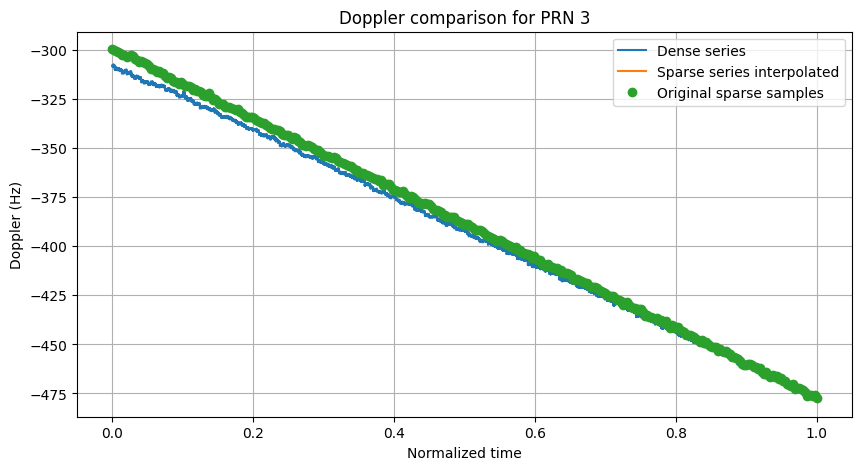

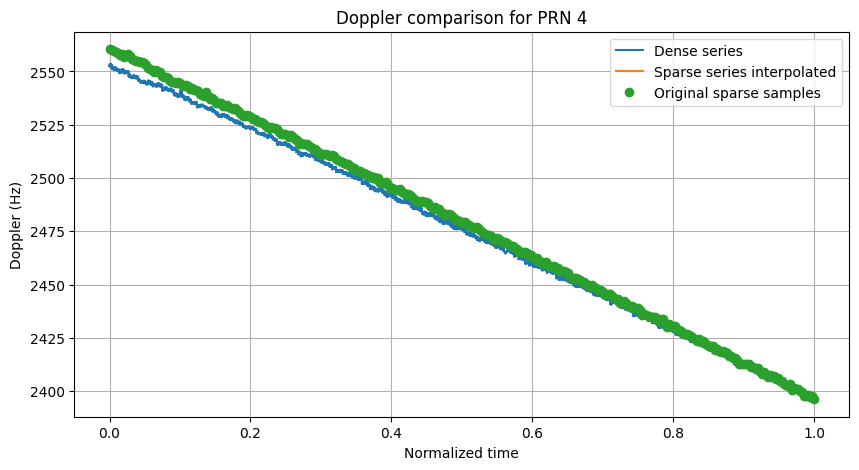

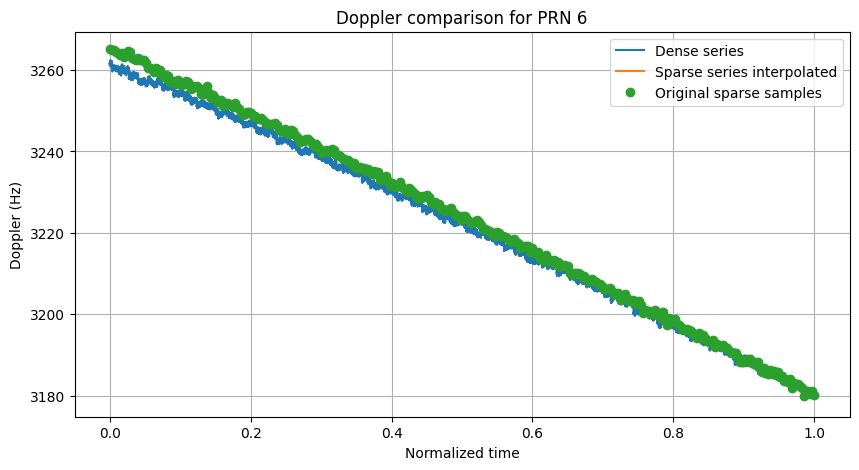

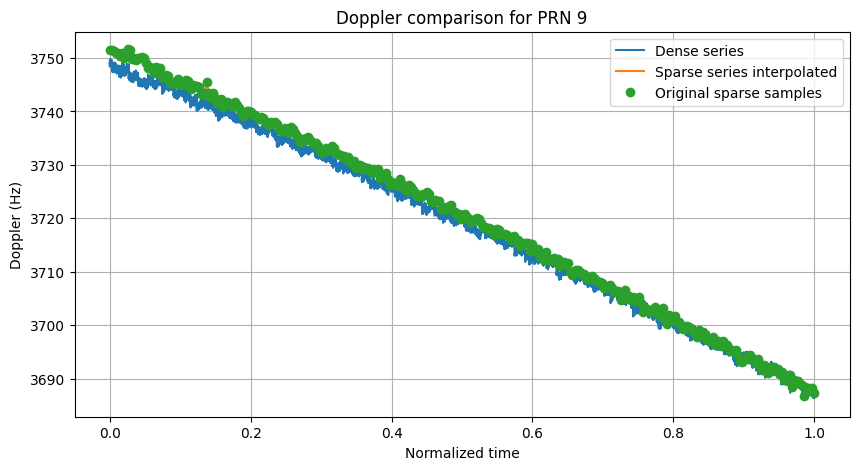

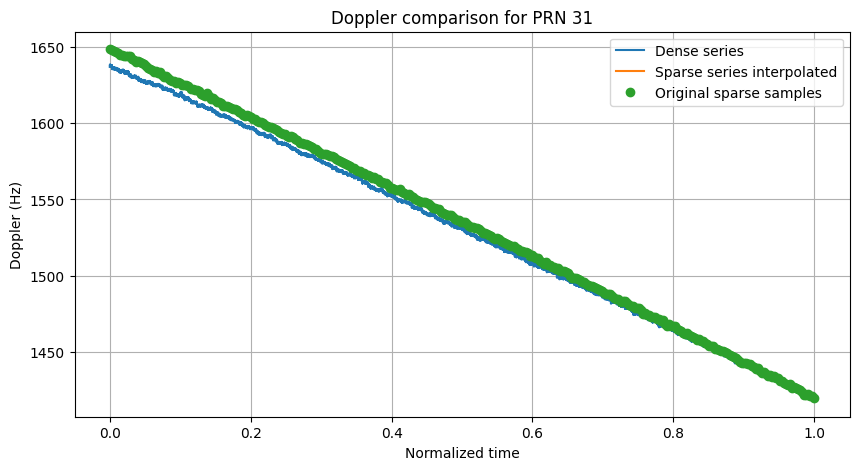

In [38]:
import numpy as np
import matplotlib.pyplot as plt

prns = [3, 4, 6, 9, 31]  # must match rows of other_doppler

for idx, prn in enumerate(prns):
    if prn not in doppler_by_prn:
        print(f"Skipping PRN {prn}")
        continue

    doppler_a = np.asarray(other_doppler[idx], dtype=float)
    doppler_b = np.asarray(doppler_by_prn[prn], dtype=float)

    time_a = np.linspace(0, 1, len(doppler_a))
    time_b = np.linspace(0, 1, len(doppler_b))

    doppler_a_interp = np.interp(time_b, time_a, doppler_a)

    plt.figure(figsize=(10, 5))
    plt.plot(time_b, doppler_b, label="Dense series")
    plt.plot(time_b, doppler_a_interp, label="Sparse series interpolated")
    plt.plot(time_a, doppler_a, "o", label="Original sparse samples")
    plt.xlabel("Normalized time")
    plt.ylabel("Doppler (Hz)")
    plt.title(f"Doppler comparison for PRN {prn}")
    plt.grid(True)
    plt.legend()
    plt.show()

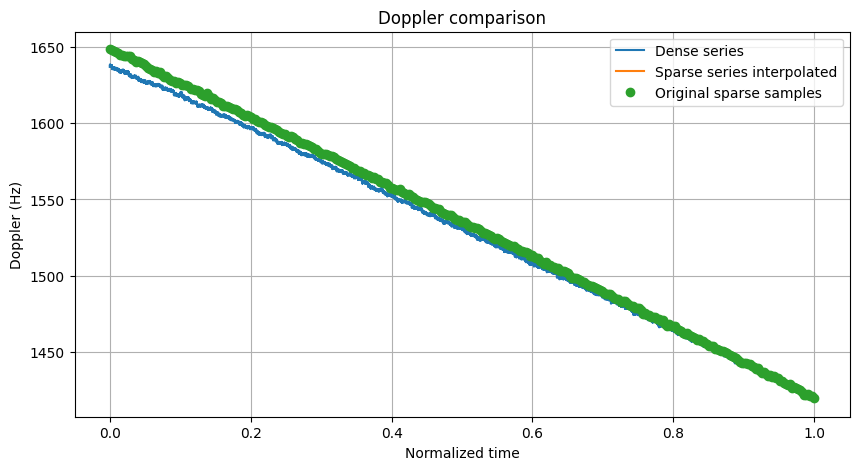

In [40]:
import numpy as np
import matplotlib.pyplot as plt

time_a = np.linspace(0, 1, len(doppler_a))
time_b = np.linspace(0, 1, len(doppler_b))

doppler_a_interp = np.interp(time_b, time_a, doppler_a)

plt.figure(figsize=(10, 5))
plt.plot(time_b, doppler_b, label="Dense series")
plt.plot(time_b, doppler_a_interp, label="Sparse series interpolated")
plt.plot(time_a, doppler_a, "o", label="Original sparse samples")
plt.xlabel("Normalized time")
plt.ylabel("Doppler (Hz)")
plt.title("Doppler comparison")
plt.grid(True)
plt.legend()
plt.show()

In [62]:
import numpy as np
import matplotlib.pyplot as plt

C_MPS = 299_792_458.0

delay_list = np.array(
    [sat_frames[f"G{sv:02d}"]["delay_s"].tolist() for sv in sv_nums],
    dtype=float
)

all_valid_df["PRN"] = all_valid_df["PRN"].astype(int)
all_valid_df = all_valid_df.sort_values(["PRN", "epoch"])

doppler_by_prn = {
    prn: grp["pseudorange_m"].to_numpy()
    for prn, grp in all_valid_df.groupby("PRN")
}

prn_list = sorted(doppler_by_prn.keys())

for i, prn in enumerate(prn_list):
    vals = doppler_by_prn[prn]

    if i >= len(delay_list):
        print(f"Skipping PRN {prn}: no matching delay row")
        continue

    print(f"PRN {prn}:")
    print(vals[-1] / C_MPS + 0.068802 - delay_list[i][350])
    print()

PRN 3:
-0.011284824059067777

PRN 4:
-0.010647738094657168

PRN 6:
-0.010482340464696968

PRN 9:
-0.01037198623357323

PRN 31:
-0.010857516129798794



In [ ]:
0.068802+0.006895-0.06689464
0.068802+0.011018-0.07101841
0.068802+0.017618-0.07761832
0.068802+0.024205-0.08420511
0.068802+0.025201-0.0852009

In [41]:
import h5py
import numpy as np
import pandas as pd


with h5py.File(mat_path, "r") as f:
    PRN = np.array(f["PRN"])
    Pseudorange_m = np.array(f["Pseudorange_m"])
    Flag_valid_pseudorange = np.array(f["Flag_valid_pseudorange"])
    RX_time = np.array(f["RX_time"])
    TOW = np.array(f["TOW_at_current_symbol_s"])

# shape expected: (channels, epochs)
valid = Flag_valid_pseudorange > 0

rows = []
n_ch, n_ep = PRN.shape

for ch in range(n_ch):
    for ep in range(n_ep):
        if valid[ch, ep]:
            rows.append({
                "channel": ch,
                "epoch": ep,
                "PRN": int(PRN[ch, ep]),
                "pseudorange_m": float(Pseudorange_m[ch, ep]),
                "rx_time_s": float(RX_time[ch, ep]),
                "tow_s": float(TOW[ch, ep]),
            })

df = pd.DataFrame(rows)

# summarize by PRN
summary = df.groupby("PRN").agg(
    n=("PRN", "size"),
    pr_min=("pseudorange_m", "min"),
    pr_max=("pseudorange_m", "max"),
    pr_mean=("pseudorange_m", "mean"),
).sort_index()

print(summary)

# bad pseudorange filter: tune threshold as needed
bad = df[(df["pseudorange_m"] < 1e6) | (df["pseudorange_m"] > 5e7)]
print("\nBad rows by PRN:")
print(bad.groupby("PRN").size())

print("\nSample bad rows:")
print(bad.head(30))

         n        pr_min        pr_max       pr_mean
PRN                                                 
3    14604 -4.060679e+06  1.992272e+07 -2.378194e+06
4    14607 -2.422904e+06  2.156049e+07 -7.407647e+05
6    14696 -3.261969e+05  2.365720e+07  1.349018e+06
9    14700 -3.576308e+05  2.362577e+07  1.317129e+06
31   14623 -1.365890e+06  2.261751e+07  3.160490e+05

Bad rows by PRN:
PRN
3     10995
4     10998
6     11085
9     11089
31    11013
dtype: int64

Sample bad rows:
      channel  epoch  PRN  pseudorange_m  rx_time_s      tow_s
6430     2202     14    6  -3.261964e+05      55.98  55.981088
6431     2203      1    9  -3.576303e+05      56.00  56.001193
6432     2203      4    3  -4.060678e+06      56.00  56.013545
6433     2203      7   31  -1.365889e+06      56.00  56.004556
6434     2203      8    4  -2.422903e+06      56.00  56.008082
6435     2203     14    6  -3.261964e+05      56.00  56.001088
6436     2204      1    9  -3.576303e+05      56.02  56.021193
6437     220

In [42]:
# inspect PRN 3 specifically
prn3 = df[df["PRN"] == 3].copy()

# rough receive-minus-transmit timing difference
prn3["dt_s"] = prn3["rx_time_s"] - prn3["tow_s"]

print(prn3[["epoch", "channel", "PRN", "pseudorange_m", "rx_time_s", "tow_s", "dt_s"]].head(50))
print("\nPRN 3 dt_s stats:")
print(prn3["dt_s"].describe())

     epoch  channel  PRN  pseudorange_m  rx_time_s      tow_s      dt_s
1        4      903    3   1.935171e+06      30.02  30.013545  0.006455
6        4      904    3   1.935170e+06      30.04  30.033545  0.006455
11       4      905    3   1.935170e+06      30.06  30.053545  0.006455
16       4      906    3   1.935171e+06      30.08  30.073545  0.006455
21       4      907    3   1.935171e+06      30.10  30.093545  0.006455
26       4      908    3   1.935171e+06      30.12  30.113545  0.006455
31       4      909    3   1.935171e+06      30.14  30.133545  0.006455
36       4      910    3   1.935171e+06      30.16  30.153545  0.006455
41       4      911    3   1.935171e+06      30.18  30.173545  0.006455
46       4      912    3   1.935171e+06      30.20  30.193545  0.006455
51       4      913    3   1.935171e+06      30.22  30.213545  0.006455
56       4      914    3   1.935171e+06      30.24  30.233545  0.006455
61       4      915    3   1.935171e+06      30.26  30.253545  0

In [43]:
with h5py.File(mat_path, "r") as f:
    PRN = np.array(f["PRN"]).T
    PR = np.array(f["Pseudorange_m"]).T
    TOW = np.array(f["TOW_at_current_symbol_s"]).T
    RX = np.array(f["RX_time"]).T
    FLAG = np.array(f["Flag_valid_pseudorange"]).T

print("PRN shape after transpose:", PRN.shape)

valid = FLAG > 0
valid_counts = np.sum(valid, axis=0)
print("max valid sats:", np.max(valid_counts))
print("epochs with >=4 valid:", np.sum(valid_counts >= 4))

best_ep = np.argmax(valid_counts)
mask = valid[:, best_ep]

print("best epoch:", best_ep)
print("PRNs:", PRN[:, best_ep][mask])
print("PR:", PR[:, best_ep][mask])
print("RX:", RX[:, best_ep][mask])
print("TOW:", TOW[:, best_ep][mask])

PRN shape after transpose: (20, 17457)
max valid sats: 5
epochs with >=4 valid: 14606
best epoch: 903
PRNs: [ 9.  3. 31.  4.  6.]
PR: [5638218.7096104  1935170.62429195 4629961.42351928 3572946.3798912
 5669652.75889472]
RX: [30.02 30.02 30.02 30.02 30.02]
TOW: [30.00119293 30.01354497 30.00455611 30.00808193 30.00108807]


In [44]:
import h5py
import numpy as np
import pandas as pd

c = 299792458.0  # speed of light [m/s]

with h5py.File(mat_path, "r") as f:
    data = {k: np.array(f[k]) for k in f.keys()}

Flag_valid_pseudorange = data["Flag_valid_pseudorange"]
PRN = data["PRN"]
Pseudorange_m = data["Pseudorange_m"]
Carrier_Doppler_hz = data["Carrier_Doppler_hz"]

n_channels, n_epochs = Flag_valid_pseudorange.shape
valid = Flag_valid_pseudorange > 0

rows = []
for e in range(n_epochs):
    for ch in np.where(valid[:, e])[0]:
        prn_val = int(PRN[ch, e])
        pr_m = float(Pseudorange_m[ch, e])
        dop_hz = float(Carrier_Doppler_hz[ch, e])

        rows.append({
            "epoch": e,
            "PRN": f"G{prn_val:02d}",
            "pseudorange_m": pr_m,
            "doppler_hz": dop_hz,
            "delay_s": pr_m / c,
        })

df = pd.DataFrame(rows)

# one row per PRN: keep first occurrence
df_one_per_prn = (
    df.sort_values(["PRN", "epoch"])
      .groupby("PRN", as_index=False)
      .first()
)

print(df_one_per_prn[["PRN", "pseudorange_m", "doppler_hz", "delay_s"]])
df_one_per_prn[["PRN", "pseudorange_m", "doppler_hz", "delay_s"]].to_csv(
    "one_row_per_prn.csv", index=False
)

   PRN  pseudorange_m   doppler_hz   delay_s
0  G03   1.935171e+06  -307.653190  0.006455
1  G04   3.572946e+06  2552.991525  0.011918
2  G06   5.669653e+06  3261.523180  0.018912
3  G09   5.638219e+06  3748.966222  0.018807
4  G31   4.629961e+06  1636.880427  0.015444


In [45]:
df_one_per_prn = (
    df.groupby("PRN", as_index=False)
      .agg({
          "pseudorange_m": "mean",
          "doppler_hz": "mean",
          "delay_s": "mean"
      })
)

print(df_one_per_prn)

   PRN  pseudorange_m   doppler_hz   delay_s
0  G03  -2.378194e+06  -392.279173 -0.007933
1  G04  -7.407647e+05  2475.665909 -0.002471
2  G06   1.349018e+06  3221.733178  0.004500
3  G09   1.317129e+06  3718.894984  0.004393
4  G31   3.160490e+05  1530.137776  0.001054


In [46]:
0.068802+0.006895-0.06689464
0.068802+0.011018-0.07101841
0.068802+0.017618-0.07761832
0.068802+0.024205-0.08420511
0.068802+0.025201-0.0852009

0.008802100000000007

In [47]:
import numpy as np

ep = 901
mask = FLAG[:, ep] > 0

prns = PRN[:, ep][mask].astype(int)
prs = PR[:, ep][mask]
tows = TOW[:, ep][mask]
rxs = RX[:, ep][mask]

print("PRNs:", prns)
print("PR spread [m]:", prs.max() - prs.min())
print("RX spread [s]:", rxs.max() - rxs.min())
print("travel times [ms]:", prs / 299792458.0 * 1e3)

for p, pr, tow in zip(prns, prs, tows):
    print(f"PRN {p:2d}: PR={pr:12.3f} m, tau={pr/299792458.0*1e3:8.3f} ms, TOW={tow:.9f}")

IndexError: index 901 is out of bounds for axis 1 with size 20

In [ ]:
rows = []
for ep in range(PR.shape[1]):
    mask = FLAG[:, ep] > 0
    if np.sum(mask) < 4:
        continue
    prns = PRN[:, ep][mask].astype(int)
    prs = PR[:, ep][mask]
    med = np.median(prs)
    for p, pr in zip(prns, prs):
        rows.append((ep, p, pr - med))

import pandas as pd
df = pd.DataFrame(rows, columns=["epoch", "PRN", "residual_to_median_m"])
print(df.groupby("PRN")["residual_to_median_m"].agg(["count","mean","std","min","max"]))

     count          mean        std           min           max
PRN                                                            
3     3482 -3.214926e+06  85.090649 -3.214930e+06 -3.212878e+06
6     3482 -1.978685e+06  85.090448 -1.978689e+06 -1.976637e+06
9     3476  0.000000e+00   0.000000  0.000000e+00  0.000000e+00
16    3482  1.974590e+06  85.091487  1.974586e+06  1.976638e+06
21    3482  2.273210e+06  85.091521  2.273206e+06  2.275258e+06


In [ ]:
ref_prns = []
for ep in range(PR.shape[1]):
    mask = FLAG[:, ep] > 0
    if np.sum(mask) < 4:
        continue
    prns = PRN[:, ep][mask].astype(int)
    tows = TOW[:, ep][mask]
    ref_prns.append(prns[np.argmax(tows)])

import pandas as pd
print(pd.Series(ref_prns).value_counts())

3    3482
Name: count, dtype: int64


In [ ]:
import h5py
import numpy as np
import pandas as pd

with h5py.File(mat_path, "r") as f:
    PRN  = np.array(f["PRN"])                    # (epochs, channels)
    PR   = np.array(f["Pseudorange_m"])
    RX   = np.array(f["RX_time"])
    TOW  = np.array(f["TOW_at_current_symbol_s"])
    FLAG = np.array(f["Flag_valid_pseudorange"])
    DOP  = np.array(f["Carrier_Doppler_hz"])

valid = (FLAG > 0) & np.isfinite(PR)
plausible = (PR > 1e6) & (PR < 5e7)
usable = valid & plausible

usable_counts = usable.sum(axis=1)
good_epochs = np.where(usable_counts >= 4)[0]

print("good epochs:", len(good_epochs))
print("first 10 good epochs:", good_epochs[:10])

# inspect a few epochs with exactly 4 usable sats
for ep in good_epochs[:10]:
    mask = usable[ep, :]
    df = pd.DataFrame({
        "channel": np.where(mask)[0],
        "PRN": PRN[ep, mask].astype(int),
        "pseudorange_m": PR[ep, mask],
        "rx_time_s": RX[ep, mask],
        "tow_s": TOW[ep, mask],
        "dt_s": RX[ep, mask] - TOW[ep, mask],
        "doppler_hz": DOP[ep, mask],
    })
    print(f"\nEpoch {ep}, usable sats = {mask.sum()}")
    print(df.sort_values("PRN"))

good epochs: 3168
first 10 good epochs: [901 902 903 904 905 906 907 908 909 910]

Epoch 901, usable sats = 5
   channel  PRN  pseudorange_m  rx_time_s      tow_s      dt_s   doppler_hz
4        7    3   2.997851e+06      36.04  36.030000  0.010000 -3221.833006
1        2    6   4.234092e+06      36.04  36.025877  0.014123  -394.766858
0        0    9   6.212781e+06      36.04  36.019276  0.020724   920.927928
3        6   16   8.187367e+06      36.04  36.012690  0.027310  2974.808828
2        3   21   8.485988e+06      36.04  36.011694  0.028306  3518.209065

Epoch 902, usable sats = 5
   channel  PRN  pseudorange_m  rx_time_s      tow_s      dt_s   doppler_hz
4        7    3   2.997851e+06      36.06  36.050000  0.010000 -3221.673948
1        2    6   4.234092e+06      36.06  36.045877  0.014123  -394.291646
0        0    9   6.212781e+06      36.06  36.039276  0.020724   920.849890
3        6   16   8.187367e+06      36.06  36.032690  0.027310  2975.006653
2        3   21   8.485988

In [ ]:
runs = []
start = None

for i, ok in enumerate(usable_counts >= 4):
    if ok and start is None:
        start = i
    elif not ok and start is not None:
        runs.append((start, i - 1, i - start))
        start = None
if start is not None:
    runs.append((start, len(usable_counts) - 1, len(usable_counts) - start))

print("Longest runs with >=4 usable sats:")
for r in sorted(runs, key=lambda x: x[2], reverse=True)[:10]:
    print(r)

Longest runs with >=4 usable sats:
(901, 2185, 1285)
(3357, 3622, 266)
(2995, 3245, 251)
(3922, 4091, 170)
(4106, 4218, 113)
(3807, 3907, 101)
(2200, 2299, 100)
(2427, 2526, 100)
(2541, 2640, 100)
(2882, 2981, 100)


In [ ]:
plausible_tight = valid & (PR > 1.5e7) & (PR < 3.5e7)
tight_counts = plausible_tight.sum(axis=1)

print("max tight usable sats:", tight_counts.max())
print("epochs with >=4 tight usable sats:", np.sum(tight_counts >= 4))

max tight usable sats: 0
epochs with >=4 tight usable sats: 0
